--- DATASET LOADED ---
Features: 30
Samples: 569
Target Distribution: [212 357] (0: Malignant, 1: Benign)

--- TRAINING BASELINE (Linear Kernel) ---
Linear SVM Accuracy: 0.9561

--- TUNING SVM (RBF Kernel) ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Score: 0.9692

--- FINAL EVALUATION ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



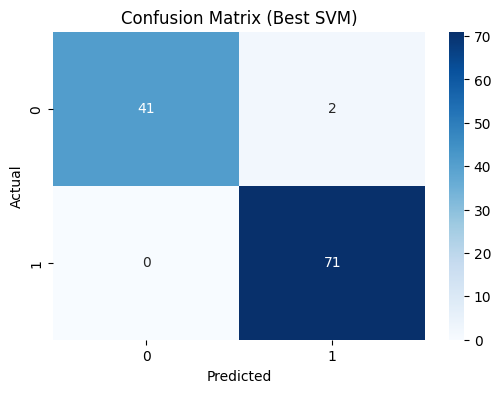

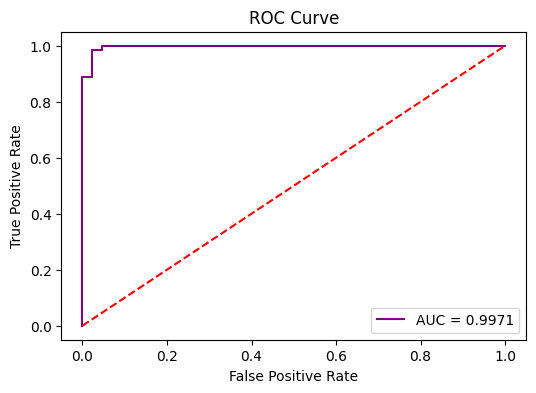


SUCCESS: Model pipeline saved as 'breast_cancer_svm_model.pkl'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import joblib

# 1. Load Dataset (Built-in, Bulletproof)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("--- DATASET LOADED ---")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Target Distribution: {np.bincount(y)} (0: Malignant, 1: Benign)")

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling (CRITICAL for SVM)
# SVM calculates distances, so unscaled data causes poor performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Baseline Model: Linear SVM
print("\n--- TRAINING BASELINE (Linear Kernel) ---")
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
linear_acc = svm_linear.score(X_test_scaled, y_test)
print(f"Linear SVM Accuracy: {linear_acc:.4f}")

# 5. Advanced Model: RBF Kernel + GridSearchCV Tuning
# We tune 'C' (Penalty) and 'gamma' (Kernel coefficient)
print("\n--- TUNING SVM (RBF Kernel) ---")
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(probability=True, random_state=42), param_grid, refit=True, verbose=1, cv=3)
grid.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_:.4f}")

# 6. Evaluation of Best Model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1] # For ROC Curve

print("\n--- FINAL EVALUATION ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Best SVM)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 7. ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='purple', label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 8. Save Model Pipeline (Scaler + Model)
# We save a dictionary containing both to ensure we scale future data correctly
pipeline = {
    'scaler': scaler,
    'model': best_model
}
joblib.dump(pipeline, 'breast_cancer_svm_model.pkl')
print("\nSUCCESS: Model pipeline saved as 'breast_cancer_svm_model.pkl'")